In [3]:
# Diagnostic cell — run this in one cell to confirm envs and test AzureChatOpenAI
from dotenv import load_dotenv
import os, traceback
from langchain_openai import AzureChatOpenAI 
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph,START,END
import operator

load_dotenv()  # ensure .env loaded

print("AZURE_OPENAI_KEY present:", bool(os.getenv("AZURE_OPENAI_KEY")))
print("AZURE_OPENAI_ENDPOINT:", os.getenv("AZURE_OPENAI_ENDPOINT"))
print("AZURE_OPENAI_DEPLOYMENT:", os.getenv("AZURE_OPENAI_DEPLOYMENT"))
print("AZURE_OPENAI_API_VERSION:", os.getenv("AZURE_OPENAI_API_VERSION"))
print("OPENAI_API_KEY (if set):", bool(os.getenv("OPENAI_API_KEY")))

# Map env names the SDK might look for (non-destructive)
if os.getenv("AZURE_OPENAI_KEY") and not os.getenv("AZURE_OPENAI_API_KEY"):
    os.environ["AZURE_OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_KEY")
if os.getenv("AZURE_OPENAI_KEY") and not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_KEY")

# Instantiate explicitly with api_key to avoid env name issues
try:
    model = AzureChatOpenAI(
        azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION", "2024-12-01-preview"),
        temperature=0.2,
        api_key=os.getenv("AZURE_OPENAI_KEY"),  # explicit
    )
    print('AzureChatOpenAI instantiated OK')
except Exception as e:
    print('Failed to instantiate AzureChatOpenAI:')
    traceback.print_exc()

# Try a short call (small tokens) to test end-to-end
try:
    resp = model.invoke("Say hello in one short sentence.")
    print("Invoke result:", getattr(resp, "content", None) or resp)
except Exception as e:
    print('Error during invoke:')
    traceback.print_exc()

AZURE_OPENAI_KEY present: True
AZURE_OPENAI_ENDPOINT: https://crr-openai-esg.openai.azure.com/
AZURE_OPENAI_DEPLOYMENT: gpt-4o-mini
AZURE_OPENAI_API_VERSION: 2024-12-01-preview
OPENAI_API_KEY (if set): True
AzureChatOpenAI instantiated OK
Invoke result: Hello!


In [2]:
from pydantic import BaseModel,Field
class EvaluationSchema(BaseModel):
    feedback :str = Field(description='Detail feedback for the easy')
    score    :int =  Field(description='score out of 10',ge =0 ,le =10)
    

In [3]:
structure_model=  model.with_structured_output(EvaluationSchema)


In [4]:
essay = """ A good diet is very important for staying healthy and strong. It helps our body grow, gives us energy, and protects us from diseases. A balanced diet means eating the right amount of different types of food.

A good diet includes fruits, vegetables, grains, pulses, milk, and nuts. Fruits and vegetables give vitamins and minerals. Grains like rice and wheat give energy. Milk and pulses give protein which helps in building muscles. We should also drink enough water every day.

We must avoid junk food like chips, cold drinks, and sweets because they are not good for our health. Eating at the right time and in the right amount is also important.

In short, a good diet keeps our body fit and our mind fresh. If we eat healthy food every day, we can live a happy and active life."""

In [5]:
promt = f'Evaluate the the esay and give the feedback and give a score out of 10\n {essay}'
structure_model.invoke(promt).score


7

In [6]:
class UPSCState(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback :str
    clarity_feedback :str
    overall_feedback : str
    individual_score : Annotated[ list[int],operator.add]
    avg_score :float
    

In [7]:
# def evaluate_language(state : UPSCState):
#     promt = f'Evaluate language quality of the esay and give the feedback and give a score out of 10\n {essay}'
#     output = structure_model.invoke(promt)
#     return {'language_feedback':output.feedback , 'individual_score':[output.score]}

In [8]:
# def evaluate_analysis(state : UPSCState):
#     promt = f'Evaluate depth of analysis of the esay and give the feedback and give a score out of 10\n {essay}'
#     output = structure_model.invoke(promt)
#     return {'analysis_feedback':output.feedback , 'individual_score':[output.score]}

In [9]:
# def evaluate_tought(state : UPSCState):
#     promt = f'Evaluate clarity of thought the esay and give the feedback and give a score out of 10\n {essay}'
#     output = structure_model.invoke(promt)
#     return {'clarity_feedback':output.feedback , 'individual_score':[output.score]}

In [10]:
# def final_evaluation(state : UPSCState):
#     #summary
#     promt = f'Based on the following feedbacks create a summarized feedback\n language feedback - {state["analysis_feedback"]} \n clarity of the thought feedback - {state["clarity_feedback"]} \n Evalute of the tought - { state["overall_feedback"]}'
#     overall_feedback = model.invoke(promt).content

#     avg_score  = sum(state["individual_score"]/len(state['individual_score']))

#     return {'overall_feedback' : overall_feedback , 'avg_score': avg_score}

In [11]:
# ...existing code...
def evaluate_language(state: UPSCState):
    prompt = f"Evaluate the language quality of the essay and give feedback + score out of 10\n\n{state['essay']}"
    output = structure_model.invoke(prompt)
    return {'language_feedback': output.feedback, 'individual_score': [output.score]}

def evaluate_analysis(state: UPSCState):
    prompt = f"Evaluate depth of analysis of the essay and give feedback + score out of 10\n\n{state['essay']}"
    output = structure_model.invoke(prompt)
    return {'analysis_feedback': output.feedback, 'individual_score': [output.score]}

def evaluate_tought(state: UPSCState):
    prompt = f"Evaluate clarity of thought of the essay and give feedback + score out of 10\n\n{state['essay']}"
    output = structure_model.invoke(prompt)
    return {'clarity_feedback': output.feedback, 'individual_score': [output.score]}

def final_evaluation(state: UPSCState):
    # gather available feedbacks (use get to avoid KeyError)
    lang_fb = state.get('language_feedback', '')
    analysis_fb = state.get('analysis_feedback', '')
    clarity_fb = state.get('clarity_feedback', '')

    prompt = (
        "Based on the following feedbacks create a summarized overall feedback:\n\n"
        f"Language feedback: {lang_fb}\n\n"
        f"Analysis feedback: {analysis_fb}\n\n"
        f"Clarity feedback: {clarity_fb}\n"
    )
    overall_feedback = model.invoke(prompt).content

    # combine individual_score entries (they may be lists appended by nodes)
    raw_scores = state.get('individual_score', [])
    flattened = []
    for item in raw_scores:
        if isinstance(item, list):
            flattened.extend(item)
        else:
            flattened.append(item)
    avg_score = sum(flattened) / len(flattened) if flattened else 0.0

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
# ...existing code...

In [12]:
graph = StateGraph(UPSCState)

graph.add_node ('evaluate_language' , evaluate_language)
graph.add_node ('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluat_thought',evaluate_tought)
graph.add_node('final_evaluation',final_evaluation)

In [13]:
# edeges
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluat_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluat_thought','final_evaluation')

graph.add_edge('final_evaluation',END)

workflow =graph.compile()

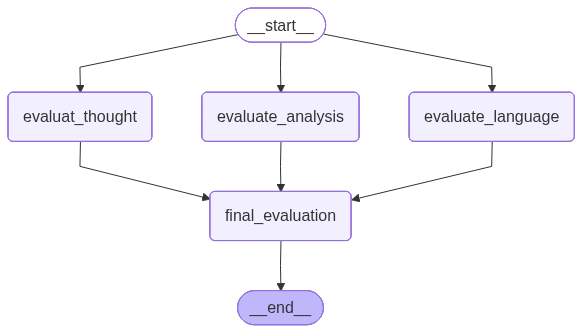

In [14]:
workflow

In [15]:
initial_state = {
    'essay' :essay
}

workflow.invoke(initial_state)

{'essay': ' A good diet is very important for staying healthy and strong. It helps our body grow, gives us energy, and protects us from diseases. A balanced diet means eating the right amount of different types of food.\n\nA good diet includes fruits, vegetables, grains, pulses, milk, and nuts. Fruits and vegetables give vitamins and minerals. Grains like rice and wheat give energy. Milk and pulses give protein which helps in building muscles. We should also drink enough water every day.\n\nWe must avoid junk food like chips, cold drinks, and sweets because they are not good for our health. Eating at the right time and in the right amount is also important.\n\nIn short, a good diet keeps our body fit and our mind fresh. If we eat healthy food every day, we can live a happy and active life.',
 'language_feedback': 'The essay presents a clear and concise argument about the importance of a good diet. The structure is logical, with an introduction, body, and conclusion. However, the langua